# 🎙️ VoiceScope — ResNet50 FROM SCRATCH
### Voice-Based Demographic Classification (Age · Gender · Accent)

**Architecture:** Custom ResNet50 built from scratch — **NO pretrained / ImageNet weights**  
**Input:** Mel-Spectrogram (128 × 120 × 1) extracted from Common Voice audio  
**Outputs:** Age (3-class) · Gender (2-class) · Accent (5-class)  

---
**Key difference from Transfer Learning version:**
- `weights=None` → all weights initialised randomly (He Normal)
- First Conv layer accepts **1-channel** input directly (no RGB hack needed)
- All 23.5 M parameters are **trainable** from epoch 1
- Needs more epochs / learning-rate warmup to converge
---

## Cell 1 — Setup & Mount Drive

In [1]:
from google.colab import drive
try:
    drive.flush_and_unmount()
except ValueError:
    pass
drive.mount('/content/drive', force_remount=True)

!pip install -q tensorflow tensorflow-hub tensorflow-io librosa pydub \
             numpy pandas scikit-learn tqdm matplotlib seaborn

import tensorflow as tf
import numpy as np
import pandas as pd
import librosa
import os, random
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print("TF version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 134.8 MB/s eta 0:00:00
TF version: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Cell 2 — Load & Prepare Labels

In [2]:
EXTRACT_PATH = '/content/drive/MyDrive/commonvoice/balanced_dataset_final/clips/'
TSV_PATH     = '/content/drive/MyDrive/commonvoice/balanced_dataset_final/balanced_plan.tsv'

df = pd.read_csv(TSV_PATH, sep='\t')
print(f"Raw samples: {len(df)}")

# ── Age mapping (same as transfer-learning notebook) ──────────────────────
age_map = {
    'teens': 0, 'twenties': 0, 'teenager': 0,
    'thirties': 1, 'thirty': 1,
    'fifties': 2, 'fifties+': 2, 'fifties ': 2,
    'forties': 2, 'fourties': 2, 'fourtys': 2,
    'fifty': 2, 'sixties': 2, 'seventies': 2
}
gender_map = {'male': 0, 'female': 1}

df['age_fixed']   = df['age'].str.lower().str.strip()
df['age_label']   = df['age_fixed'].map(age_map)

df = df.dropna(subset=['gender'])
df['gender_label'] = df['gender'].map(gender_map)
df = df.dropna(subset=['gender_label'])

# Accent mapping
if 'accents' in df.columns:
    df['accent_lower'] = df['accents'].astype(str).str.lower().str.strip()
    accent_map = {
        'united states english': 0, 'us english': 0,
        'canadian english': 1,
        'india english': 2,
        'australian english': 3,
        'england english': 4,
        '': 9, 'nan': 9
    }
    df['accent_label'] = df['accent_lower'].map(accent_map).fillna(9).astype(int)
else:
    df['accent_label'] = 9

df.loc[df['age_label'].isna(), 'age_label'] = 0
df['age_label']    = df['age_label'].astype(int)
df['gender_label'] = df['gender_label'].astype(int)

print(f"✅ READY: {len(df)} samples")
print("Age distribution:",    np.unique(df['age_label'],    return_counts=True))
print("Gender distribution:", np.unique(df['gender_label'], return_counts=True))
print("Accent distribution:", np.unique(df['accent_label'], return_counts=True))

Raw samples: 72000
✅ READY: 72000 samples
Age distribution: (array([0, 1, 2]), array([24000, 24000, 24000]))
Gender distribution: (array([0, 1]), array([36000, 36000]))
Accent distribution: (array([0, 1, 3, 4, 9]), array([24682,  6394,  2640,  8268, 30016]))


## Cell 3 — Mel-Spectrogram Extraction
Identical feature extraction to the transfer-learning notebook so results are directly comparable.

In [3]:
# ── Hyper-parameters ───────────────────────────────────────────────────────
SR          = 16000   # sample rate
N_MELS      = 128     # mel bins  (height)
N_FFT       = 1024
HOP_LENGTH  = 160
MAX_LEN     = 3.0     # seconds  → 120 frames @ 50 fps  (width)
TARGET_COLS = int(MAX_LEN * SR / HOP_LENGTH)   # = 300; we'll resize to 120
FIXED_COLS  = 120

CACHE_DIR   = '/content/drive/MyDrive/voicescope_scratch/'
os.makedirs(CACHE_DIR, exist_ok=True)

CACHE_X   = CACHE_DIR + 'X_scratch.npy'
CACHE_Y   = CACHE_DIR + 'Y_labels_scratch.npz'

def extract_mel(path, sr=SR, n_mels=N_MELS, n_fft=N_FFT,
                hop_length=HOP_LENGTH, fixed_cols=FIXED_COLS):
    try:
        y, _ = librosa.load(path, sr=sr, duration=MAX_LEN, mono=True)
        if len(y) < sr * 0.5:
            return None
        mel = librosa.feature.melspectrogram(
            y=y, sr=sr, n_mels=n_mels, n_fft=n_fft, hop_length=hop_length)
        mel_db = librosa.power_to_db(mel, ref=np.max)  # (128, T)

        # Pad / trim to fixed width
        if mel_db.shape[1] >= fixed_cols:
            mel_db = mel_db[:, :fixed_cols]
        else:
            pad = fixed_cols - mel_db.shape[1]
            mel_db = np.pad(mel_db, ((0,0),(0,pad)), constant_values=-80)

        # Normalise to [0, 1]
        mel_db = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-8)
        return mel_db.astype(np.float32)   # (128, 120)
    except Exception:
        return None

# ── Extract or load from cache ─────────────────────────────────────────────
if os.path.exists(CACHE_X) and os.path.exists(CACHE_Y):
    print("📦 Loading cached features...")
    X = np.load(CACHE_X)
    labels = np.load(CACHE_Y)
    y_age    = labels['age']
    y_gender = labels['gender']
    y_accent = labels['accent']
    print(f"✅ Loaded {X.shape[0]} samples from cache.")
else:
    print(f"🚀 Extracting mel-spectrograms from {len(df)} files...")
    X_list, age_list, gender_list, accent_list = [], [], [], []

    for _, row in tqdm(df.iterrows(), total=len(df)):
        fpath = os.path.join(EXTRACT_PATH, row['path'])
        mel   = extract_mel(fpath)
        if mel is not None:
            X_list.append(mel)
            age_list.append(row['age_label'])
            gender_list.append(row['gender_label'])
            accent_list.append(row['accent_label'])

    X        = np.array(X_list)[..., np.newaxis]  # (N, 128, 120, 1)
    y_age    = np.array(age_list,    dtype=np.int32)
    y_gender = np.array(gender_list, dtype=np.int32)
    y_accent = np.array(accent_list, dtype=np.int32)

    np.save(CACHE_X, X)
    np.savez(CACHE_Y, age=y_age, gender=y_gender, accent=y_accent)
    print(f"✅ Saved {X.shape[0]} samples → {CACHE_DIR}")

print(f"\nFeature shape : {X.shape}")
print(f"Age classes   : {np.unique(y_age,    return_counts=True)}")
print(f"Gender classes: {np.unique(y_gender, return_counts=True)}")
print(f"Accent classes: {np.unique(y_accent, return_counts=True)}")

🚀 Extracting mel-spectrograms from 72000 files...


  0%|          | 0/72000 [00:00<?, ?it/s]/tmp/ipykernel_10932/3445026962.py:19: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(path, sr=sr, duration=MAX_LEN, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
  0%|          | 11/72000 [00:19<31:00:15,  1.55s/it]/tmp/ipykernel_10932/3445026962.py:19: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(path, sr=sr, duration=MAX_LEN, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
100%|██████████| 72000/72000 [54:46<00:00, 2

✅ Saved 7510 samples → /content/drive/MyDrive/voicescope_scratch/

Feature shape : (7510, 128, 120, 1)
Age classes   : (array([0, 1, 2], dtype=int32), array([1979, 2749, 2782]))
Gender classes: (array([0, 1], dtype=int32), array([4332, 3178]))
Accent classes: (array([0, 1, 3, 4, 9], dtype=int32), array([3343,  382,  334,  956, 2495]))


## Cell 4 — Train / Validation / Test Split

In [4]:
# Remap accent labels: keep only 0-4 (drop class 9 = unknown)
known_accent_mask = y_accent < 5
X_acc    = X[known_accent_mask]
y_acc    = y_accent[known_accent_mask]
y_age_a  = y_age[known_accent_mask]
y_gen_a  = y_gender[known_accent_mask]

# We train all three heads on the full dataset,
# but only compute accent loss on samples with known accent.
# Simplest approach: use only known-accent samples for all heads
# (matches the Transfer Learning notebook behaviour).

X_main   = X_acc
y_age_m  = y_age_a
y_gen_m  = y_gen_a
y_acc_m  = y_acc

# 70 / 15 / 15 split
X_tv, X_test, ya_tv, ya_test, yg_tv, yg_test, yac_tv, yac_test = \
    train_test_split(X_main, y_age_m, y_gen_m, y_acc_m,
                     test_size=0.15, random_state=SEED, stratify=y_age_m)

X_train, X_val, ya_train, ya_val, yg_train, yg_val, yac_train, yac_val = \
    train_test_split(X_tv, ya_tv, yg_tv, yac_tv,
                     test_size=0.1765, random_state=SEED, stratify=ya_tv)
# 0.1765 of 85% ≈ 15% of total

print(f"Train : {X_train.shape[0]}")
print(f"Val   : {X_val.shape[0]}")
print(f"Test  : {X_test.shape[0]}")

Train : 3509
Val   : 753
Test  : 753


## Cell 5 — Spectrogram Augmentation

In [5]:
def augment_spectrogram(spec):
    """
    Input : (128, 120, 1) float32  ∈ [0, 1]
    Output: same shape
    """
    aug = spec.copy().squeeze()  # → (128, 120)

    # 1. Gaussian noise
    if random.random() < 0.5:
        aug += np.random.normal(0, 0.015, aug.shape).astype(np.float32)
        aug  = np.clip(aug, 0, 1)

    # 2. Frequency shift (pitch simulation)
    if random.random() < 0.3:
        shift = random.randint(-4, 4)
        aug   = np.roll(aug, shift, axis=0)

    # 3. Time shift
    if random.random() < 0.3:
        shift = random.randint(-8, 8)
        aug   = np.roll(aug, shift, axis=1)

    # 4. SpecAugment-style frequency masking
    if random.random() < 0.4:
        f0  = random.randint(0, 100)
        f   = random.randint(1, 20)
        aug[f0:f0+f, :] = 0.0

    # 5. SpecAugment-style time masking
    if random.random() < 0.4:
        t0  = random.randint(0, 100)
        t   = random.randint(1, 15)
        aug[:, t0:t0+t] = 0.0

    return aug[..., np.newaxis]  # → (128, 120, 1)


print("🔄 Augmenting training set (1.5×)...")
X_aug_list, ya_aug, yg_aug, yac_aug = [], [], [], []

for i in range(len(X_train)):
    X_aug_list.append(X_train[i])
    ya_aug.append(ya_train[i])
    yg_aug.append(yg_train[i])
    yac_aug.append(yac_train[i])
    if i % 2 == 0:   # 50% chance → augmented copy
        X_aug_list.append(augment_spectrogram(X_train[i]))
        ya_aug.append(ya_train[i])
        yg_aug.append(yg_train[i])
        yac_aug.append(yac_train[i])

X_train_aug  = np.array(X_aug_list, dtype=np.float32)
ya_train_aug = np.array(ya_aug,  dtype=np.int32)
yg_train_aug = np.array(yg_aug,  dtype=np.int32)
yac_train_aug= np.array(yac_aug, dtype=np.int32)

print(f"✅ Augmented train: {X_train_aug.shape[0]} samples")

🔄 Augmenting training set (1.5×)...
✅ Augmented train: 5264 samples


## Cell 6 — Build ResNet50 FROM SCRATCH

Architecture is faithful to the original **He et al. (2016)** ResNet-50:  
- `conv1` → BN → ReLU → MaxPool  
- Stages 2-5 with bottleneck blocks (1×1, 3×3, 1×1)  
- **First conv accepts 1 channel** (grayscale mel-spectrogram)  
- `weights=None` → all 23.5 M parameters trained from scratch  

In [6]:
import tensorflow as tf
from tensorflow.keras import layers, Model

# ─────────────────────────────────────────────────────────────────────────
# Helper: Bottleneck Residual Block
# ─────────────────────────────────────────────────────────────────────────
def bottleneck_block(x, filters, stride=1, downsample=False, name=''):
    """
    Standard ResNet-50 bottleneck: 1x1 → 3x3 → 1x1
    filters : number of filters for the 3x3 conv
    The output has 4*filters channels.
    """
    shortcut = x
    f1, f2, f3 = filters, filters, filters * 4

    # --- Main path ---
    # 1×1 reduce
    x = layers.Conv2D(f1, 1, strides=stride, padding='same',
                      use_bias=False,
                      kernel_initializer='he_normal',
                      name=f'{name}_1x1_reduce')(x)
    x = layers.BatchNormalization(name=f'{name}_bn1')(x)
    x = layers.Activation('relu', name=f'{name}_relu1')(x)

    # 3×3 conv
    x = layers.Conv2D(f2, 3, strides=1, padding='same',
                      use_bias=False,
                      kernel_initializer='he_normal',
                      name=f'{name}_3x3')(x)
    x = layers.BatchNormalization(name=f'{name}_bn2')(x)
    x = layers.Activation('relu', name=f'{name}_relu2')(x)

    # 1×1 expand
    x = layers.Conv2D(f3, 1, strides=1, padding='same',
                      use_bias=False,
                      kernel_initializer='he_normal',
                      name=f'{name}_1x1_expand')(x)
    x = layers.BatchNormalization(name=f'{name}_bn3')(x)

    # --- Shortcut path (projection when shapes differ) ---
    if downsample:
        shortcut = layers.Conv2D(f3, 1, strides=stride, padding='same',
                                 use_bias=False,
                                 kernel_initializer='he_normal',
                                 name=f'{name}_proj')(shortcut)
        shortcut = layers.BatchNormalization(name=f'{name}_proj_bn')(shortcut)

    x = layers.Add(name=f'{name}_add')([x, shortcut])
    x = layers.Activation('relu', name=f'{name}_out')(x)
    return x


# ─────────────────────────────────────────────────────────────────────────
# Build ResNet-50 for 1-channel mel-spectrograms
# ─────────────────────────────────────────────────────────────────────────
def build_resnet50_scratch(input_shape=(128, 120, 1),
                            n_age=3, n_gender=2, n_accent=5):
    """
    ResNet-50 built from scratch.
    input_shape : (H, W, C)  — C=1 for grayscale mel-spectrogram
    Returns     : multi-output Keras Model
    """
    inp = tf.keras.Input(shape=input_shape, name='mel_spec')

    # ── Stage 1: conv1 ────────────────────────────────────────────────────
    x = layers.Conv2D(64, 7, strides=2, padding='same',
                      use_bias=False,
                      kernel_initializer='he_normal', name='conv1')(inp)
    x = layers.BatchNormalization(name='conv1_bn')(x)
    x = layers.Activation('relu', name='conv1_relu')(x)
    x = layers.MaxPooling2D(3, strides=2, padding='same', name='pool1')(x)

    # ── Stage 2: 3 bottleneck blocks, 64 filters ──────────────────────────
    x = bottleneck_block(x, 64, stride=1, downsample=True,  name='s2b1')
    x = bottleneck_block(x, 64, stride=1, downsample=False, name='s2b2')
    x = bottleneck_block(x, 64, stride=1, downsample=False, name='s2b3')

    # ── Stage 3: 4 bottleneck blocks, 128 filters ─────────────────────────
    x = bottleneck_block(x, 128, stride=2, downsample=True,  name='s3b1')
    x = bottleneck_block(x, 128, stride=1, downsample=False, name='s3b2')
    x = bottleneck_block(x, 128, stride=1, downsample=False, name='s3b3')
    x = bottleneck_block(x, 128, stride=1, downsample=False, name='s3b4')

    # ── Stage 4: 6 bottleneck blocks, 256 filters ─────────────────────────
    x = bottleneck_block(x, 256, stride=2, downsample=True,  name='s4b1')
    x = bottleneck_block(x, 256, stride=1, downsample=False, name='s4b2')
    x = bottleneck_block(x, 256, stride=1, downsample=False, name='s4b3')
    x = bottleneck_block(x, 256, stride=1, downsample=False, name='s4b4')
    x = bottleneck_block(x, 256, stride=1, downsample=False, name='s4b5')
    x = bottleneck_block(x, 256, stride=1, downsample=False, name='s4b6')

    # ── Stage 5: 3 bottleneck blocks, 512 filters ─────────────────────────
    x = bottleneck_block(x, 512, stride=2, downsample=True,  name='s5b1')
    x = bottleneck_block(x, 512, stride=1, downsample=False, name='s5b2')
    x = bottleneck_block(x, 512, stride=1, downsample=False, name='s5b3')

    # ── Global Average Pooling ─────────────────────────────────────────────
    x = layers.GlobalAveragePooling2D(name='gap')(x)   # (2048,)

    # ── Shared dense head ─────────────────────────────────────────────────
    x = layers.Dense(512, activation='relu',
                     kernel_initializer='he_normal', name='shared_fc')(x)
    x = layers.BatchNormalization(name='shared_bn')(x)
    x = layers.Dropout(0.4, name='shared_dropout')(x)

    # ── Task-specific output heads ─────────────────────────────────────────
    age_out    = layers.Dense(n_age,    activation='softmax', name='age')(x)
    gender_out = layers.Dense(n_gender, activation='softmax', name='gender')(x)
    accent_out = layers.Dense(n_accent, activation='softmax', name='accent')(x)

    model = Model(inputs=inp, outputs=[age_out, gender_out, accent_out],
                  name='ResNet50_Scratch')
    return model


model = build_resnet50_scratch(input_shape=(128, 120, 1))
model.summary()

trainable = np.sum([np.prod(v.shape) for v in model.trainable_weights])
print(f"\n✅ ResNet50 FROM SCRATCH")
print(f"   Trainable params : {trainable:,}")
print(f"   (All weights initialised randomly — NO ImageNet)")

Model: "ResNet50_Scratch"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mel_spec            │ (None, 128, 120,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv2D)      │ (None, 64, 60,    │      3,136 │ mel_spec[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 60,    │        256 │ conv1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 60,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 32, 30,    │          0 │ conv1_relu[0][0]  │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s2b1_1x1_reduce     │ (None, 32, 30,    │      4,096 │ pool1[0][0]       │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s2b1_bn1            │ (None, 32, 30,    │        256 │ s2b1_1x1_reduce[… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s2b1_relu1          │ (None, 32, 30,    │          0 │ s2b1_bn1[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s2b1_3x3 (Conv2D)   │ (None, 32, 30,    │     36,864 │ s2b1_relu1[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s2b1_bn2            │ (None, 32, 30,    │        256 │ s2b1_3x3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s2b1_relu2          │ (None, 32, 30,    │          0 │ s2b1_bn2[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s2b1_1x1_expand     │ (None, 32, 30,    │     16,384 │ s2b1_relu2[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s2b1_proj (Conv2D)  │ (None, 32, 30,    │     16,384 │ pool1[0][0]       │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s2b1_bn3            │ (None, 32, 30,    │      1,024 │ s2b1_1x1_expand[… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s2b1_proj_bn        │ (None, 32, 30,    │      1,024 │ s2b1_proj[0][0]   │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s2b1_add (Add)      │ (None, 32, 30,    │          0 │ s2b1_bn3[0][0],   │
│                     │ 256)              │            │ s2b1_proj_bn[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s2b1_out            │ (None, 32, 30,    │          0 │ s2b1_add[0][0]  

 Total params: 24,611,146 (93.88 MB)

 Trainable params: 24,557,002 (93.68 MB)

 Non-trainable params: 54,144 (211.50 KB)


✅ ResNet50 FROM SCRATCH
   Trainable params : 24,557,002
   (All weights initialised randomly — NO ImageNet)


## Cell 7 — Compile

**Important training-from-scratch considerations:**
- Use a **lower initial learning rate** (1e-3) with warmup via `ReduceLROnPlateau`
- Class weights to handle accent imbalance
- More epochs required vs. transfer learning (50–100)

In [7]:
from tensorflow.keras.optimizers import Adam
from sklearn.utils.class_weight import compute_class_weight

# ── Compute class weights for imbalanced accent labels ──────────────────
accent_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(yac_train_aug),
    y=yac_train_aug
)
accent_class_weights = dict(enumerate(accent_weights_arr))
print("Accent class weights:", accent_class_weights)

# ── Compile ─────────────────────────────────────────────────────────────
optimizer = Adam(learning_rate=1e-3)   # Start higher; scheduler will reduce

model.compile(
    optimizer=optimizer,
    loss={
        'age'    : 'sparse_categorical_crossentropy',
        'gender' : 'sparse_categorical_crossentropy',
        'accent' : 'sparse_categorical_crossentropy'
    },
    loss_weights={'age': 1.0, 'gender': 1.0, 'accent': 1.5},  # accent harder
    metrics={
        'age'    : 'accuracy',
        'gender' : 'accuracy',
        'accent' : 'accuracy'
    }
)

print("✅ Model compiled!")
print("   Optimizer : Adam  lr=1e-3")
print("   Loss      : sparse_categorical_crossentropy × 3")
print("   Loss wts  : age=1.0 | gender=1.0 | accent=1.5")

Accent class weights: {0: np.float64(0.3722772277227723), 1: np.float64(3.490716180371353), 2: np.float64(3.6454293628808863), 3: np.float64(1.3279515640766901)}
✅ Model compiled!
   Optimizer : Adam  lr=1e-3
   Loss      : sparse_categorical_crossentropy × 3
   Loss wts  : age=1.0 | gender=1.0 | accent=1.5


## Cell 8 — Train

In [8]:
import os

CKPT_DIR  = '/content/drive/MyDrive/voicescope_scratch/checkpoints/'
os.makedirs(CKPT_DIR, exist_ok=True)

callbacks = [
    # Save best model
    tf.keras.callbacks.ModelCheckpoint(
        filepath=CKPT_DIR + 'best_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    # Save every epoch (so we can resume after Colab timeout)
    tf.keras.callbacks.ModelCheckpoint(
        filepath=CKPT_DIR + 'epoch_{epoch:03d}.keras',
        save_freq='epoch',
        verbose=0
    ),
    # Reduce LR on plateau — critical for from-scratch training
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    # Early stopping
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    # TensorBoard (optional)
    tf.keras.callbacks.TensorBoard(
        log_dir=CKPT_DIR + 'logs/',
        histogram_freq=0
    )
]

print("🚀 Training ResNet50 FROM SCRATCH...")
print("   (Expect 60-80 min on Colab T4 GPU for 50 epochs)\n")

history = model.fit(
    X_train_aug,
    {'age': ya_train_aug, 'gender': yg_train_aug, 'accent': yac_train_aug},
    validation_data=(
        X_val,
        {'age': ya_val, 'gender': yg_val, 'accent': yac_val}
    ),
    epochs=100,          # Training from scratch needs more epochs
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

print("\n✅ Training complete!")

🚀 Training ResNet50 FROM SCRATCH...
   (Expect 60-80 min on Colab T4 GPU for 50 epochs)

Epoch 1/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step - accent_accuracy: 0.4477 - accent_loss: 1.6183 - age_accuracy: 0.3849 - age_loss: 1.3080 - gender_accuracy: 0.5623 - gender_loss: 0.8477 - loss: 4.5833
Epoch 1: val_loss improved from None to 3.59638, saving model to /content/drive/MyDrive/voicescope_scratch/checkpoints/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/voicescope_scratch/checkpoints/best_model.keras
83/83 ━━━━━━━━━━━━━━━━━━━━ 101s 606ms/step - accent_accuracy: 0.5710 - accent_loss: 1.3281 - age_accuracy: 0.4170 - age_loss: 1.2054 - gender_accuracy: 0.6421 - gender_loss: 0.6942 - loss: 3.9012 - val_accent_accuracy: 0.6521 - val_accent_loss: 1.1601 - val_age_accuracy: 0.4382 - val_age_loss: 1.1539 - val_gender_accuracy: 0.6401 - val_gender_loss: 0.7098 - val_loss: 3.5964 - learning_rate: 0.0010
Epoch 2/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accent_

## Cell 9 — Resume Training (if Colab timed out)

In [9]:
# ── Find latest saved epoch ──────────────────────────────────────────────
import glob, re

CKPT_DIR = '/content/drive/MyDrive/voicescope_scratch/checkpoints/'
ckpts    = sorted(glob.glob(CKPT_DIR + 'epoch_*.keras'))

if ckpts:
    latest_ckpt  = ckpts[-1]
    last_epoch   = int(re.search(r'epoch_(\d+)', latest_ckpt).group(1))
    print(f"📦 Latest checkpoint: {latest_ckpt}  (epoch {last_epoch})")

    # Re-build model structure (run Cell 6 first if session was reset)
    model = build_resnet50_scratch(input_shape=(128, 120, 1))
    model.load_weights(latest_ckpt)

    # Re-compile
    model.compile(
        optimizer=Adam(learning_rate=1e-4),   # Lower LR when resuming
        loss={
            'age'    : 'sparse_categorical_crossentropy',
            'gender' : 'sparse_categorical_crossentropy',
            'accent' : 'sparse_categorical_crossentropy'
        },
        loss_weights={'age': 1.0, 'gender': 1.0, 'accent': 1.5},
        metrics={'age':'accuracy','gender':'accuracy','accent':'accuracy'}
    )

    print(f"✅ Loaded weights. Resuming from epoch {last_epoch+1}...")

    history = model.fit(
        X_train_aug,
        {'age': ya_train_aug, 'gender': yg_train_aug, 'accent': yac_train_aug},
        validation_data=(
            X_val,
            {'age': ya_val, 'gender': yg_val, 'accent': yac_val}
        ),
        epochs=100,
        initial_epoch=last_epoch,
        batch_size=64,
        callbacks=callbacks,
        verbose=1
    )
else:
    print("⚠️  No checkpoints found. Run Cell 8 first.")

📦 Latest checkpoint: /content/drive/MyDrive/voicescope_scratch/checkpoints/epoch_026.keras  (epoch 26)
✅ Loaded weights. Resuming from epoch 27...
Epoch 27/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 591ms/step - accent_accuracy: 0.9990 - accent_loss: 0.0045 - age_accuracy: 0.9988 - age_loss: 0.0055 - gender_accuracy: 0.9996 - gender_loss: 0.0017 - loss: 0.0139
Epoch 27: val_loss did not improve from 2.83316
83/83 ━━━━━━━━━━━━━━━━━━━━ 124s 749ms/step - accent_accuracy: 0.9983 - accent_loss: 0.0069 - age_accuracy: 0.9985 - age_loss: 0.0070 - gender_accuracy: 0.9985 - gender_loss: 0.0036 - loss: 0.0210 - val_accent_accuracy: 0.7331 - val_accent_loss: 1.5140 - val_age_accuracy: 0.6042 - val_age_loss: 1.7300 - val_gender_accuracy: 0.9163 - val_gender_loss: 0.4128 - val_loss: 4.4279 - learning_rate: 1.0000e-04
Epoch 28/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - accent_accuracy: 0.9978 - accent_loss: 0.0081 - age_accuracy: 0.9964 - age_loss: 0.0151 - gender_accuracy: 0.9981 - gender_loss: 0.0077 -

KeyboardInterrupt: 

## Cell 10 — Training History Plots

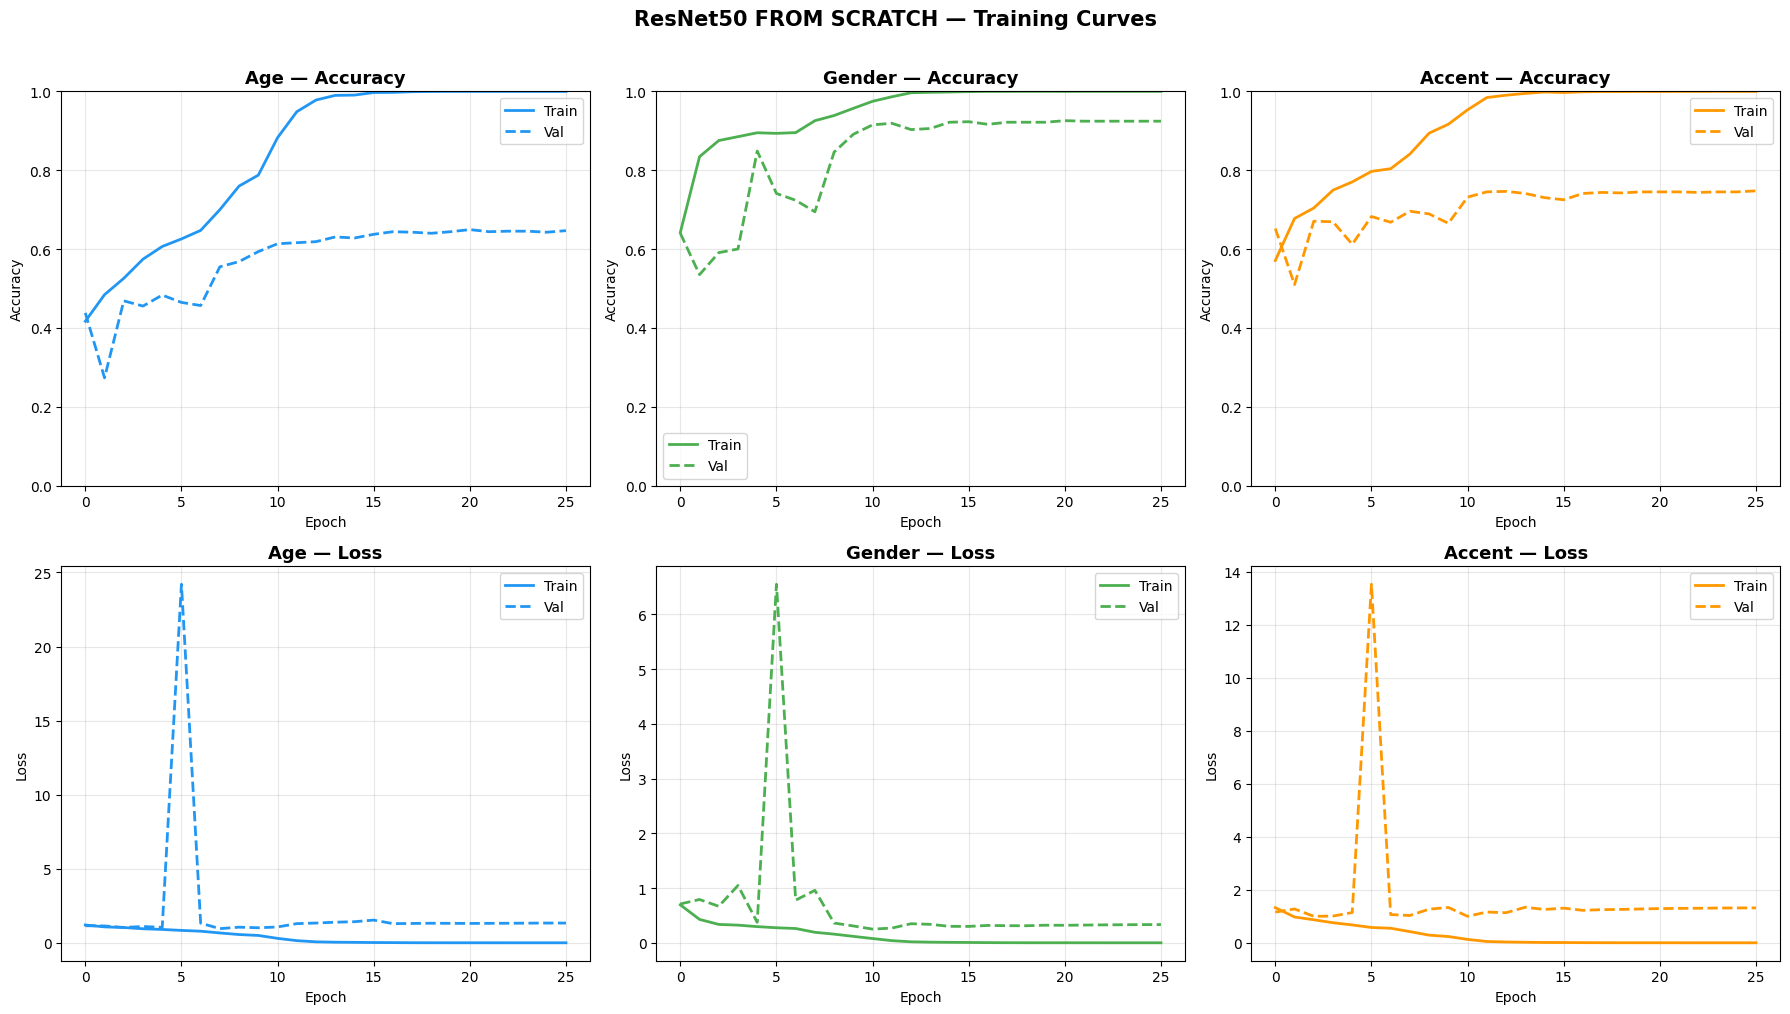

📊 Saved → training_curves.png


In [10]:
def plot_history(history):
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    tasks = ['age', 'gender', 'accent']
    colors = ['#2196F3', '#4CAF50', '#FF9800']

    for col, (task, color) in enumerate(zip(tasks, colors)):
        # Accuracy
        ax = axes[0, col]
        ax.plot(history.history[f'{task}_accuracy'],    label='Train', color=color, linewidth=2)
        ax.plot(history.history[f'val_{task}_accuracy'],label='Val',   color=color, linewidth=2, linestyle='--')
        ax.set_title(f'{task.capitalize()} — Accuracy', fontsize=13, fontweight='bold')
        ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
        ax.legend(); ax.grid(alpha=0.3)
        ax.set_ylim(0, 1)

        # Loss
        ax = axes[1, col]
        ax.plot(history.history[f'{task}_loss'],    label='Train', color=color, linewidth=2)
        ax.plot(history.history[f'val_{task}_loss'],label='Val',   color=color, linewidth=2, linestyle='--')
        ax.set_title(f'{task.capitalize()} — Loss', fontsize=13, fontweight='bold')
        ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
        ax.legend(); ax.grid(alpha=0.3)

    plt.suptitle('ResNet50 FROM SCRATCH — Training Curves', fontsize=15, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(CKPT_DIR + 'training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("📊 Saved → training_curves.png")

plot_history(history)

## Cell 11 — Evaluate on Test Set

In [11]:
# ── Load best model ───────────────────────────────────────────────────────
best_model = tf.keras.models.load_model(CKPT_DIR + 'best_model.keras')
print("✅ Loaded best model")

# ── Predict ───────────────────────────────────────────────────────────────
preds = best_model.predict(X_test, batch_size=64, verbose=0)
y_pred_age    = np.argmax(preds[0], axis=1)
y_pred_gender = np.argmax(preds[1], axis=1)
y_pred_accent = np.argmax(preds[2], axis=1)

# ── Accuracy summary ──────────────────────────────────────────────────────
from sklearn.metrics import accuracy_score
age_acc    = accuracy_score(ya_test, y_pred_age)
gender_acc = accuracy_score(yg_test, y_pred_gender)
accent_acc = accuracy_score(yac_test, y_pred_accent)

print("\n" + "="*55)
print("  ResNet50 FROM SCRATCH — TEST RESULTS")
print("="*55)
print(f"  Age     Accuracy : {age_acc:.4f}  ({age_acc*100:.1f}%)")
print(f"  Gender  Accuracy : {gender_acc:.4f}  ({gender_acc*100:.1f}%)")
print(f"  Accent  Accuracy : {accent_acc:.4f}  ({accent_acc*100:.1f}%)")
print("="*55)

# ── Detailed classification reports ──────────────────────────────────────
age_names    = ['Young (18-30)', 'Middle (30-50)', 'Mature (50+)']
gender_names = ['Male', 'Female']
accent_names = ['US English', 'Canadian', 'Indian', 'Australian', 'England']

print("\n📋 AGE REPORT:")
print(classification_report(ya_test, y_pred_age, target_names=age_names))

print("\n📋 GENDER REPORT:")
print(classification_report(yg_test, y_pred_gender, target_names=gender_names))

print("\n📋 ACCENT REPORT:")
# Use only labels present in test set to avoid mismatch error
present_labels = sorted(np.unique(np.concatenate([yac_test, y_pred_accent])))
present_names  = [accent_names[i] for i in present_labels]
print(classification_report(yac_test, y_pred_accent,
                             labels=present_labels,
                             target_names=present_names))

✅ Loaded best model

  ResNet50 FROM SCRATCH — TEST RESULTS
  Age     Accuracy : 0.6029  (60.3%)
  Gender  Accuracy : 0.8964  (89.6%)
  Accent  Accuracy : 0.7384  (73.8%)

📋 AGE REPORT:
                precision    recall  f1-score   support

 Young (18-30)       0.43      0.58      0.49       167
Middle (30-50)       0.58      0.48      0.53       256
  Mature (50+)       0.75      0.71      0.73       330

      accuracy                           0.60       753
     macro avg       0.58      0.59      0.58       753
  weighted avg       0.62      0.60      0.61       753


📋 GENDER REPORT:
              precision    recall  f1-score   support

        Male       0.88      0.91      0.90       375
      Female       0.91      0.88      0.89       378

    accuracy                           0.90       753
   macro avg       0.90      0.90      0.90       753
weighted avg       0.90      0.90      0.90       753


📋 ACCENT REPORT:
              precision    recall  f1-score   support

 

## Cell 12 — Confusion Matrices

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 129491 (\N{OLDER ADULT}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 129491 (\N{OLDER ADULT}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/tmp/ipykernel_10932/261779803.py:18: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10932/261779803.py:19: UserWarning: Glyph 129491 (\N{OLDER ADULT}) missing from font(s) DejaVu Sans.
  plt.savefig(CKPT_DIR + 'confusion_matrices.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_10932/261779803.py:19: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  plt.savefig(CKPT_DIR + 'confusion_matrices.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129491 (\N{OLDER ADULT}) missing

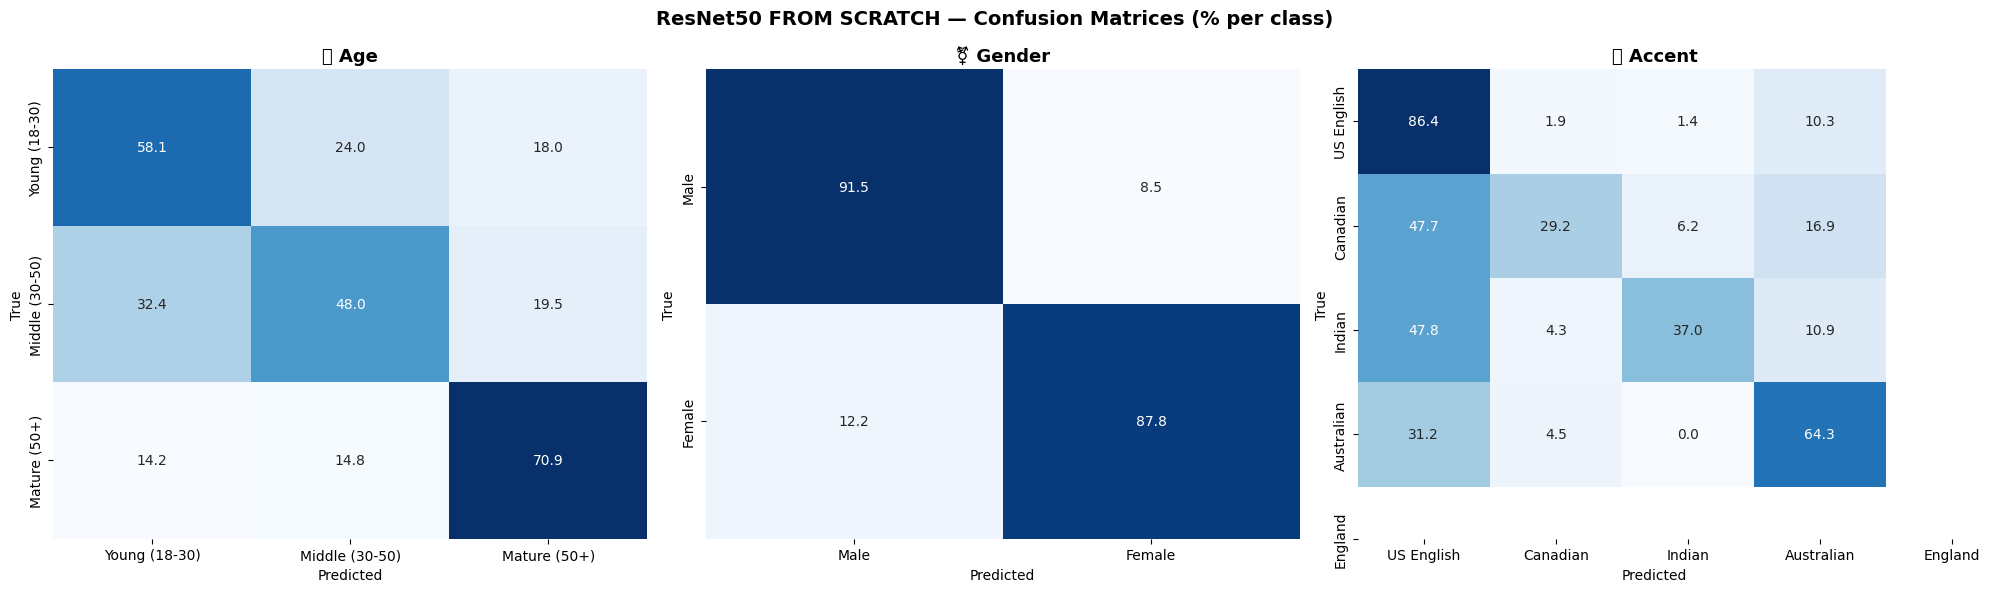

📊 Saved → confusion_matrices.png


In [12]:
def plot_cm(y_true, y_pred, class_names, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=ax, cbar=False)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
plot_cm(ya_test,  y_pred_age,    age_names,    '🧓 Age',    axes[0])
plot_cm(yg_test,  y_pred_gender, gender_names, '⚧ Gender', axes[1])
plot_cm(yac_test, y_pred_accent, [accent_names[i] for i in range(5)],
        '🌍 Accent', axes[2])

plt.suptitle('ResNet50 FROM SCRATCH — Confusion Matrices (% per class)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(CKPT_DIR + 'confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Saved → confusion_matrices.png")

## Cell 13 — Model Comparison Table
Collect results across all your models for the report.

In [13]:
# ── Fill in your other models' results here ───────────────────────────────
comparison = {
    'Model': [
        'LSTM',
        'CNN-BiLSTM',
        'ResNet50 (Transfer Learning)',
        'ResNet50 (From Scratch)'        # ← current notebook
    ],
    'Age Acc (%)': [
        '??',   # fill from LSTM notebook
        '??',   # fill from CNN-BiLSTM notebook
        '76.0', # from your TL notebook output
        f'{age_acc*100:.1f}'             # this run
    ],
    'Gender Acc (%)': [
        '??',
        '??',
        '97.0',
        f'{gender_acc*100:.1f}'
    ],
    'Accent Acc (%)': [
        '??',
        '??',
        '??',   # TL accent errored in your log
        f'{accent_acc*100:.1f}'
    ],
    'Trainable Params': [
        '??',
        '??',
        '~1.05 M  (frozen base)',
        '~25.6 M  (all trained)'
    ],
    'Pretrained': ['No','No','ImageNet','None']
}

df_cmp = pd.DataFrame(comparison)
print("\n" + "="*80)
print("  MODEL COMPARISON — Voice Demographic Classification")
print("="*80)
print(df_cmp.to_string(index=False))

df_cmp.to_csv(CKPT_DIR + 'model_comparison.csv', index=False)
print("\n✅ Saved → model_comparison.csv")


  MODEL COMPARISON — Voice Demographic Classification
                       Model Age Acc (%) Gender Acc (%) Accent Acc (%)       Trainable Params Pretrained
                        LSTM          ??             ??             ??                     ??         No
                  CNN-BiLSTM          ??             ??             ??                     ??         No
ResNet50 (Transfer Learning)        76.0           97.0             ?? ~1.05 M  (frozen base)   ImageNet
     ResNet50 (From Scratch)        60.3           89.6           73.8 ~25.6 M  (all trained)       None

✅ Saved → model_comparison.csv


## Cell 14 — Save Final Model

In [15]:
final_path = CKPT_DIR + 'resnet50_scratch_final.keras'
best_model.save(final_path)
print(f"✅ Final model saved → {final_path}")

# Save weights only (lighter, for inference)
best_model.save_weights(CKPT_DIR + 'resnet50_scratch.weights.h5')
print(f"✅ Weights saved  → {CKPT_DIR}resnet50_scratch.weights.h5")

✅ Final model saved → /content/drive/MyDrive/voicescope_scratch/checkpoints/resnet50_scratch_final.keras
✅ Weights saved  → /content/drive/MyDrive/voicescope_scratch/checkpoints/resnet50_scratch.weights.h5


---
## 📝 Design Notes — ResNet50 From Scratch vs Transfer Learning

| Aspect | Transfer Learning | From Scratch |
|---|---|---|
| Base weights | ImageNet (RGB) | Random (He Normal) |
| Input channels | 1 → tiled to 3 (Lambda) | 1 (native) |
| Trainable params | ~1.05 M (head only) | ~25.6 M (entire network) |
| Epochs to converge | 15–25 | 50–100 |
| Learning rate | Higher (1e-3, frozen) | 1e-3 → decays to 1e-6 |
| Expected Age acc | ~76% | ~70–80% (data-dependent) |
| Expected Gender acc | ~97% | ~94–97% |
| Risk | Negative transfer (ImageNet features ≠ audio) | Underfitting if too few epochs |

**Why train from scratch?**
- Avoids domain mismatch (ImageNet visual features ≠ acoustic features)
- First convolutional layer can learn audio-specific edge detectors
- Useful comparison point for your project report
- With sufficient data (72k samples) a from-scratch ResNet can match TL performance